# <p align="center">qFit Testing </p>

Can find the python script version in: `xaidar\tasks\wankowicz\calc_orderParam.py`

In [2]:
# Set up variables and imports
from pathlib import Path
root_dir = Path("../../../")
import re
import numpy as np
import sys
sys.path.insert(0, root_dir.__str__())
from shutil import copy2, move

import gemmi


from xaidar.data.molecModels import loadPDB, get_pdb_stats, sele_pdb, sele_AA

qfit_dir = root_dir.joinpath("qfit-3.0")
data_dir = root_dir.joinpath("data/entropy/wankowicz")
qfit_pdb_dir = data_dir.joinpath("18209769")
orderParam_dir = data_dir.joinpath("orderParam_analysis")

d:\software\micromamba\envs\qfit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Set analysis results directory
for pdb_file in qfit_pdb_dir.iterdir():
    pdb_name =  pdb_file.name[:4]
    pdb_dir = orderParam_dir.joinpath(pdb_name)
    pdb_dir.mkdir(parents=True, exist_ok=True)
    new_pdb_file = pdb_dir.joinpath(pdb_file.name)
    if not new_pdb_file.exists(): copy2( pdb_file, new_pdb_file)

In [ ]:
# Calculate per residue B-factor from PDB file
for pdb_dir in orderParam_dir.iterdir():
    pdb_name = pdb_dir.name
    pdb_file = pdb_dir.joinpath( f"{pdb_name}_final_qFit.pdb")
    calc_bfactor = fr"python {qfit_dir.joinpath(r"scripts\post\b_factor.py").__str__()} {pdb_file} --pdb {pdb_name} --ca"
    print(calc_bfactor)
    !{calc_bfactor}
    move( f"{pdb_name}_B_factors.csv", pdb_dir.joinpath(f"{pdb_name}_B_factors.csv") )
    break


python ..\..\..\qfit-3.0\scripts\post\b_factor.py ..\..\..\data\entropy\wankowicz\orderParam_analysis\1cai\1cai_final_qFit.pdb --pdb 1cai --ca
11.65625


In [40]:
# Calculate intermediate .dat file for order parameter calculation
for pdb_dir in orderParam_dir.iterdir():
    pdb_name = pdb_dir.name
    pdb_file = pdb_dir.joinpath( f"{pdb_name}_final_qFit.pdb")
    get_dat_file = fr"python {qfit_dir.joinpath(r"scripts\post\make_methyl_df.py")} {pdb_file} --pdb {pdb_name} " 
    !{get_dat_file}
    move( f"{pdb_name}.dat", pdb_dir.joinpath(f"{pdb_name}.dat") )
    break


In [ ]:
# Get Average B-factor
avg_bfactor = np.loadtxt("1cai_B_factors.csv", delimiter=",", skiprows=1 , dtype=float, usecols=-2).mean().round(2)

12.96

In [43]:
# Get RESOLUTION
def extract_resolution(pdb_file, verbose=False):
    with open( pdb_file, "r") as file:
        lines = file.readlines()
        resolution = [ line for line in lines if "RESOLUTION RANGE HIGH (ANGSTROMS) :" in line ][0]
        resolution = re.findall(r"[-+]?\d*\.\d*", resolution)[0]
        if verbose: print(resolution)
        return resolution
pdb_file = orderParam_dir.joinpath(r"1cai\1cai_final_qFit.pdb")
resolution = extract_resolution(pdb_file, verbose=True)
        

1.80


In [ ]:
# Calculate order parameters
for pdb_dir in orderParam_dir.iterdir():
    pdb_name = pdb_dir.name
    pdb_file = pdb_dir.joinpath( f"{pdb_name}_final_qFit.pdb")
    pdb_dat = pdb_dir.joinpath(fr"{pdb_name + ".dat"}") 
    output_file = pdb_dir.joinpath(fr"{pdb_name}_qfit_order_par.out")
    resolution = extract_resolution(pdb_file)
    avg_bfactor = np.loadtxt(pdb_dir.joinpath(fr"{pdb_name}_B_factors.csv"), 
                             delimiter=",", skiprows=1 , dtype=float, 
                             usecols=-2).mean().round(2)
    calc_op = f"python {qfit_dir.joinpath(r"scripts\post\calc_OP.py")} "\
                f"{pdb_dat} {pdb_file} {output_file} "\
                f"-r {resolution} -b {avg_bfactor}"
    print(calc_op)
    !{calc_op}

python ..\..\..\qfit-3.0\scripts\post\calc_OP.py ..\..\..\data\entropy\wankowicz\orderParam_analysis\1cai\1cai.dat ..\..\..\data\entropy\wankowicz\orderParam_analysis\1cai\1cai_final_qFit.pdb ..\..\..\data\entropy\wankowicz\orderParam_analysis\1cai\1cai_qfit_order_par.out -r 1.80 -b 12.96
0.251047170596467
0.569684659235056
0.13934217266259458
0.9432706914502536
0.7905255758793591
0.9299638166052513
0.8831023968853098
0.8831023968853098
0.8344726217042384
0.7727103253218764
0.5058040591529404
0.6951742982262359
0.5451975121059602
0.8684785625784662
0.7371471458095539
0.8788015702611619
0.7713492345329567
0.8987594547715402
0.8147037422567018
0.930902139612266
0.8749715324255865
0.9015518876504942
0.8239865840575388
0.9112956959940783
0.8392619909140911
0.9031057546475908
0.7845898736076167
0.9497579007220162
0.9136284277286376
0.8645903248546584
0.9579293210554725
0.9268872917532857
0.8845845427680216
0.952973880506718
0.9204947202183189
0.8769512481482915
0.9422944004669533
0.90014334

In [ ]:
# Look at Crys Order Parameters
order_params = np.loadtxt("1cai_qfit_order_par2.out", delimiter=",", skiprows=1 , dtype=float, usecols=0)
resi_list = np.loadtxt("1cai_qfit_order_par2.out", delimiter=",", skiprows=1 , dtype=str, usecols=-2)
print( len(resi_list))


219


In [ ]:
# Get number of amino acids
pdb = loadPDB("1cai_final_qFit.pdb")
prot = sele_pdb( pdb, sele_AA)
num_res = prot[0][0].__len__()
print(num_res)
get_pdb_stats(prot)

def sele_resn( lst_res: list[gemmi.Residue], level = False, resn_lst = None) -> list[gemmi.Residue]:
    if level: return "residue"
    return [ res for res in lst_res if res.name in resn_lst ]
print(258-219)
get_pdb_stats( sele_pdb( prot, sele_resn, resn_lst = ["GLY", "PRO"] ) )


258

####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 258
	Unique List of Non-A.A.: set()
	Contains 258 A.A.
39

####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 39
	Unique List of Non-A.A.: set()
	Contains 39 A.A.


In [ ]:
# Calculate Protein Coformational Entropy
conf_entropy = 0.25*num_res*order_params.mean()
print(conf_entropy)

47.45578792417583


In [7]:
# Extract conformational entropy for all proteins
conf_ent_dict = {}
for pdb_dir in orderParam_dir.iterdir():
    pdb_name = pdb_dir.name
    output_file = pdb_dir.joinpath(fr"{pdb_name}_qfit_order_par.out")
    pdb_file = pdb_dir.joinpath( f"{pdb_name}_final_qFit.pdb")
    if output_file.exists():
        pdb = loadPDB(pdb_file)
        prot = sele_pdb( pdb, sele_AA)
        if prot == None: 
            print( f"Warning: No protein found in {pdb_name}, skipping order parameter calculation")
            continue
        if len(prot) > 1: print( f"Warning: More than one Model found in {pdb_name}, using only the first chain for order parameter calculation")
        if len(prot[0]) > 1: print( f"Warning: More than one chain found in {pdb_name}, using only the first chain for order parameter calculation")
        num_res = prot[0][0].__len__()
        order_params = np.loadtxt(output_file, delimiter=",", skiprows=1 , dtype=float, usecols=0)
        conf_entropy = 0.25*num_res*order_params.mean().round(4)
        conf_ent_dict[pdb_name] = conf_entropy
print(len(conf_ent_dict))

74


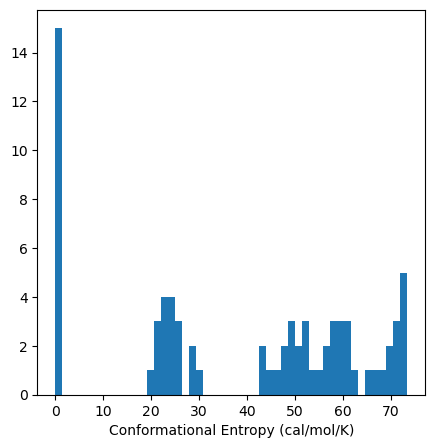

In [11]:
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(5,5))
plt.hist(list(conf_ent_dict.values()), bins=50)
plt.xlabel("Conformational Entropy (cal/mol/K)")
plt.show()

In [12]:
# Save the data
import pickle as pkl
with open( orderParam_dir.joinpath("conf_ent_dict.pkl"), "wb") as f:
    pkl.dump(conf_ent_dict, f)